Exploratory Data Analysis for TF-IDF Vectorized ISW Reports

This script generates visualizations to explore the structure
of a TF-IDF vectorized dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
df = pd.read_csv("<your path for vectorised dataset>", index_col=0)

1. PCA Projection

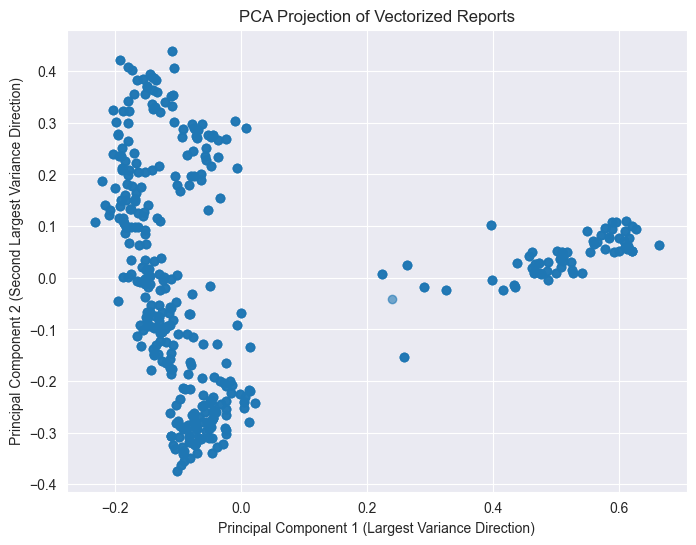

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)

plt.title("PCA Projection of Vectorized Reports")
plt.xlabel("Principal Component 1 (Largest Variance Direction)")
plt.ylabel("Principal Component 2 (Second Largest Variance Direction)")

plt.show()


2. t-SNE Visualization

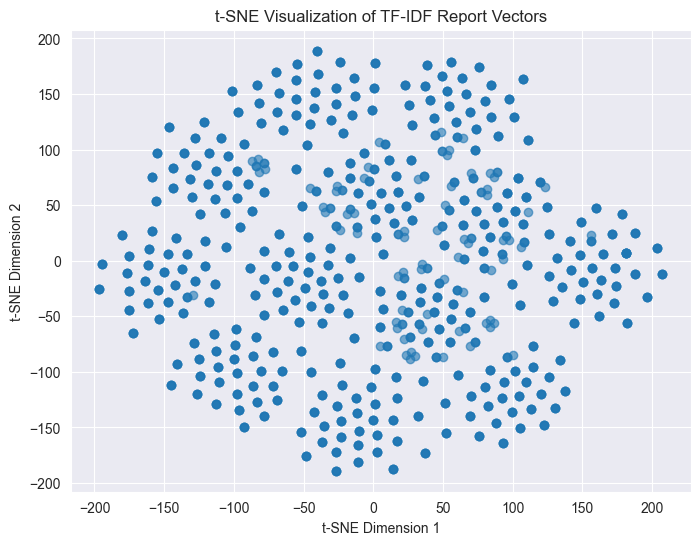

In [9]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.6)

plt.title("t-SNE Visualization of TF-IDF Report Vectors")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

3. K-Means Clustering

/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


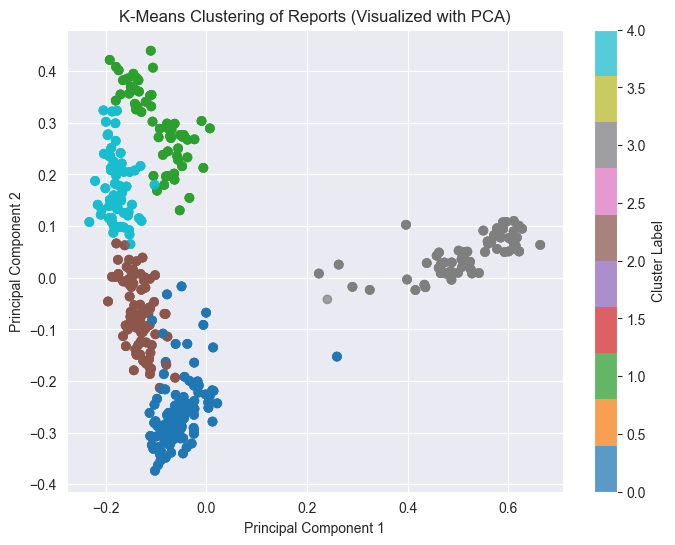

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(df)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="tab10",
    alpha=0.7
)

plt.title("K-Means Clustering of Reports (Visualized with PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster Label")

plt.show()

4. Cosine Similarity Heatmap

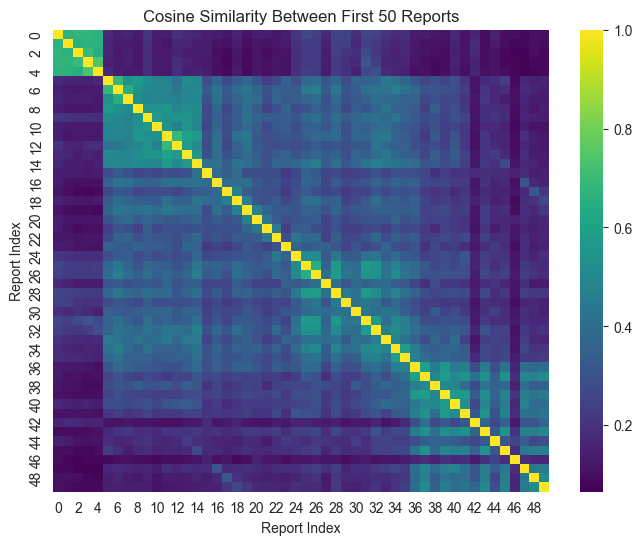

In [11]:
subset = df.iloc[:50]
similarity_matrix = cosine_similarity(subset)

plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_matrix,
    cmap="viridis"
)

plt.title("Cosine Similarity Between First 50 Reports")
plt.xlabel("Report Index")
plt.ylabel("Report Index")

plt.show()

 5. Sparsity Analysis

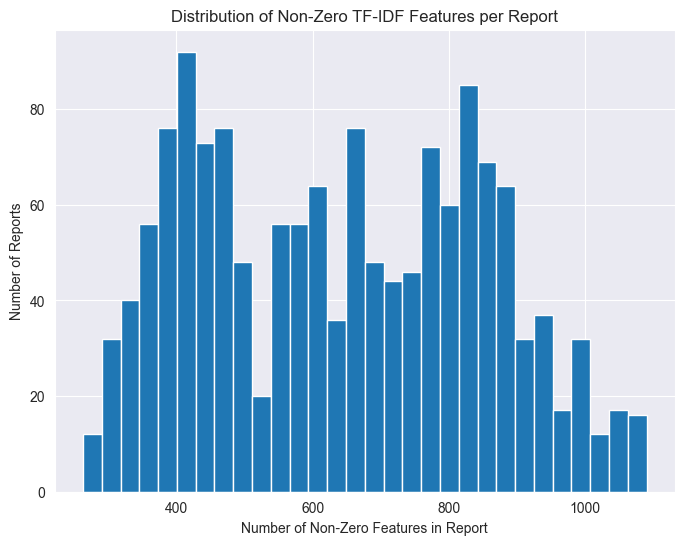

In [12]:
nonzero_counts = (df != 0).sum(axis=1)

plt.figure(figsize=(8,6))

plt.hist(nonzero_counts, bins=30)

plt.title("Distribution of Non-Zero TF-IDF Features per Report")
plt.xlabel("Number of Non-Zero Features in Report")
plt.ylabel("Number of Reports")

plt.show()

6. TF-IDF Value Distribution

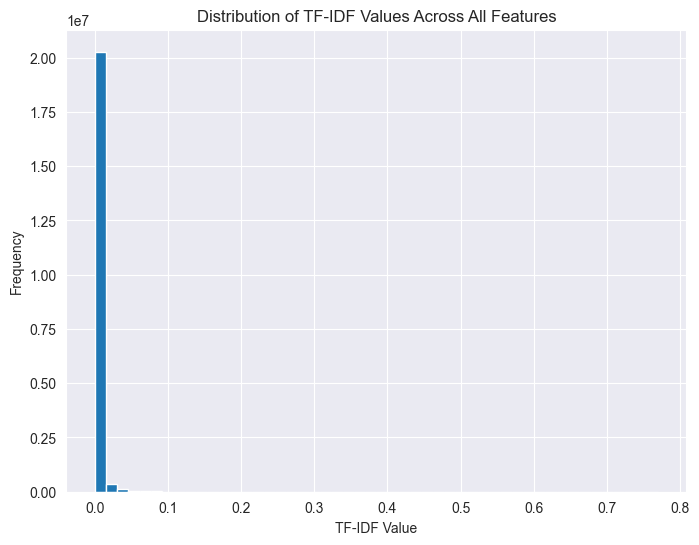

In [13]:
values = df.values.flatten()

plt.figure(figsize=(8,6))

plt.hist(values, bins=50)

plt.title("Distribution of TF-IDF Values Across All Features")
plt.xlabel("TF-IDF Value")
plt.ylabel("Frequency")

plt.show()

7. Feature Variance Distribution

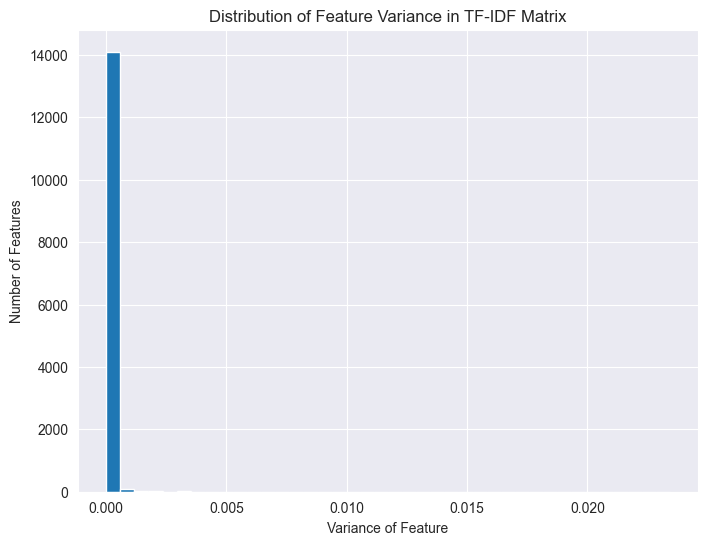

In [14]:
variance = df.var()

plt.figure(figsize=(8,6))

plt.hist(variance, bins=40)

plt.title("Distribution of Feature Variance in TF-IDF Matrix")
plt.xlabel("Variance of Feature")
plt.ylabel("Number of Features")

plt.show()


8. Feature Correlation Heatmap

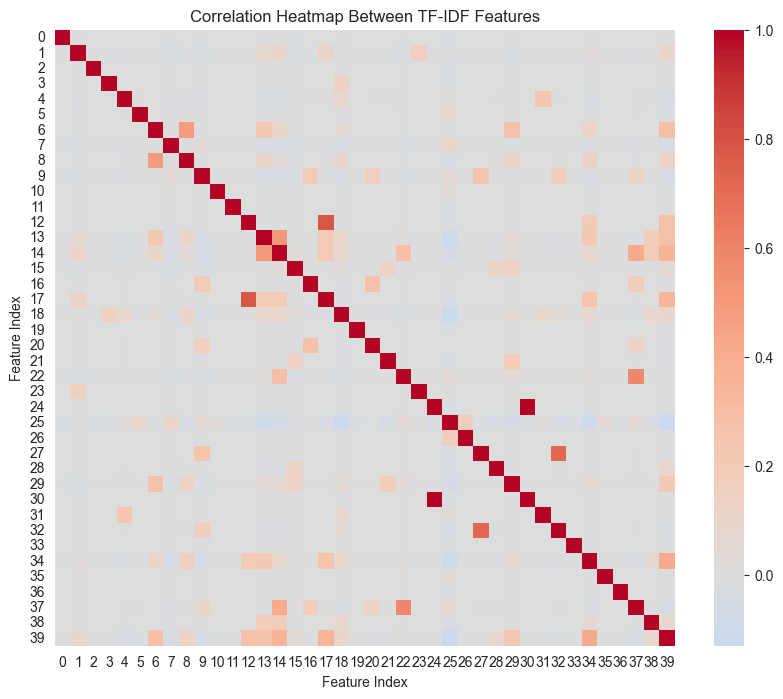

In [15]:
subset = df.iloc[:, :40]   # first 40 features
corr_matrix = subset.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap Between TF-IDF Features")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")

plt.show()